Import Bibliotek

In [185]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, img_as_float, exposure
from skimage.filters import frangi, unsharp_mask, threshold_otsu
from scipy.ndimage import gaussian_filter
from skimage.morphology import remove_small_objects, binary_closing, disk, remove_small_holes

Załadowanie obrazów

In [186]:
dnoOka = []
for i in range(1,16):
    if i < 10:
        filename1 = f"all/images/0{i}_dr.jpg"
        filename2 = f"all/images/0{i}_g.jpg"
        filename3 = f"all/images/0{i}_h.jpg"
    else:
        filename1 = f"all/images/{i}_dr.jpg"
        filename2 = f"all/images/{i}_g.jpg"
        filename3 = f"all/images/{i}_h.jpg"
        
    img1 = cv2.imread(filename1)
    img2 = cv2.imread(filename2)
    img3 = cv2.imread(filename3)
    dnoOka.append(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
    dnoOka.append(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
    dnoOka.append(cv2.cvtColor(img3, cv2.COLOR_BGR2RGB))


naczynia = []
for i in range(1,16):
    if i < 10:
        filename1 = f"all/manual1/0{i}_dr.tif"
        filename2 = f"all/manual1/0{i}_g.tif"
        filename3 = f"all/manual1/0{i}_h.tif"
    else:
        filename1 = f"all/manual1/{i}_dr.tif"
        filename2 = f"all/manual1/{i}_g.tif"
        filename3 = f"all/manual1/{i}_h.tif"
    naczynia.append(cv2.imread(filename1, cv2.IMREAD_GRAYSCALE))
    naczynia.append(cv2.imread(filename2, cv2.IMREAD_GRAYSCALE))
    naczynia.append(cv2.imread(filename3, cv2.IMREAD_GRAYSCALE))

maski = []
for i in range(1,16):
    if i < 10:
        filename1 = f"all/mask/0{i}_dr_mask.tif"
        filename2 = f"all/mask/0{i}_g_mask.tif"
        filename3 = f"all/mask/0{i}_h_mask.tif"
    else:
        filename1 = f"all/mask/{i}_dr_mask.tif"
        filename2 = f"all/mask/{i}_g_mask.tif"
        filename3 = f"all/mask/{i}_h_mask.tif"
    maski.append(cv2.imread(filename1, cv2.IMREAD_GRAYSCALE))
    maski.append(cv2.imread(filename2, cv2.IMREAD_GRAYSCALE))
    maski.append(cv2.imread(filename3, cv2.IMREAD_GRAYSCALE))
    
dnoOka = dnoOka[:5]
naczynia = naczynia[:5]
maski = maski[:5]

Wstępne Przetwarzanie

In [187]:
def preprocess(img):
    # Konwersja do skali szarości
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    
    # Odwrócenie obrazu (naczynia stają się jasne)
    inverted = 255 - gray
    
    #  dla poprawy kontrastu
    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(16, 16))
    enhanced = clahe.apply(inverted)
    
    # Korekcja gamma
    gamma_corrected = exposure.adjust_gamma(enhanced, gamma=0.7)
    
    return img_as_float(gamma_corrected)

Filtr Frangiego

In [188]:
def detect_vessels(img):
    
    # Wykrywanie cienkich naczyń (mniejsze sigmy)
    thin_vessels = frangi(
        img,
        sigmas=range(1, 4),  # Małe skale dla cienkich naczyń
        beta=0.5,
        gamma=0.01,
        black_ridges=False
    )
    
    # Wykrywanie grubych naczyń (większe sigmy)
    thick_vessels = frangi(
        img,
        sigmas=range(4, 10),  # Większe skale dla grubych naczyń
        beta=0.5,
        gamma=0.001,
        black_ridges=False
    )

    # Łączenie wyników
    combined = np.maximum(thin_vessels, thick_vessels)
    # Normalizacja wyników do zakresu [0, 1]
    return (combined - combined.min()) / (combined.max() - combined.min())

Wizualizacja

In [189]:
def compare_results(original, processed, frangi, binary, manual):
    fig, ax = plt.subplots(2, 3, figsize=(15, 10))
    
    ax[0,0].imshow(original, cmap='gray')
    ax[0,0].set_title("Oryginał")
    
    ax[0,1].imshow(processed, cmap='gray')
    ax[0,1].set_title("Przetworzony")
    
    ax[0,2].imshow(frangi, cmap='viridis')
    ax[0,2].set_title("Wynik Frangiego")
    
    ax[1,0].imshow(binary, cmap='gray')
    ax[1,0].set_title("Wykryte Naczynia")
    
    ax[1,1].imshow(manual, cmap='gray')
    ax[1,1].set_title("Ręczna Segmentacja")
    
    # Nakładka naczyń na oryginalny obraz
    overlay = original.copy()
    overlay[binary, 0] = 255 
    overlay[binary, 1] = 255
    overlay[binary, 2] = 255
    ax[1,2].imshow(overlay)
    ax[1,2].set_title("Nakładka Naczyń")
    
    for a in ax.flat:
        a.axis('off')
    
    plt.tight_layout()
    plt.show()

In [190]:
# Przetwarzanie wszystkich obrazów z listy dnoOka
processed = [preprocess(img) for img in dnoOka]

# Wykrywanie naczyń dla wszystkich przetworzonych obrazów
vessels = [detect_vessels(img) for img in processed]


Post Pocessing

In [191]:
binaries = []
for i, v in enumerate(vessels):
    # Dynamiczne progowanie (metoda Otsu)
    thresh = threshold_otsu(v)
    # Zastosowanie progu
    binary = v > thresh * 1.3 # Nieco wyższy próg, aby zmniejszyć fałszywe pozytywy
    
    # czyszczenie
    
    cleaned = binary_closing(binary, footprint=disk(1)) # Zamknięcie binarne do wypełniania małych przerw
    cleaned = remove_small_objects(cleaned, min_size=150) # Usunięcie małych, nieistotnych obiektów
    cleaned = remove_small_holes(cleaned, area_threshold=50) # Usunięcie małych dziur w naczyniach
    cleaned = cleaned * maski[i]  # mask_region to binarna maska (1 wewnątrz, 0 na zewnątrz)
    
    overlap = np.logical_and(cleaned, naczynia[i] > 0)
    coverage = np.sum(overlap) / np.sum(naczynia[i] > 0)
    print(f"Image {i+1} vessel coverage: {coverage:.2%}")
    
    binaries.append(cleaned)

Image 1 vessel coverage: 71.41%
Image 2 vessel coverage: 64.19%
Image 3 vessel coverage: 69.83%
Image 4 vessel coverage: 67.33%
Image 5 vessel coverage: 64.31%


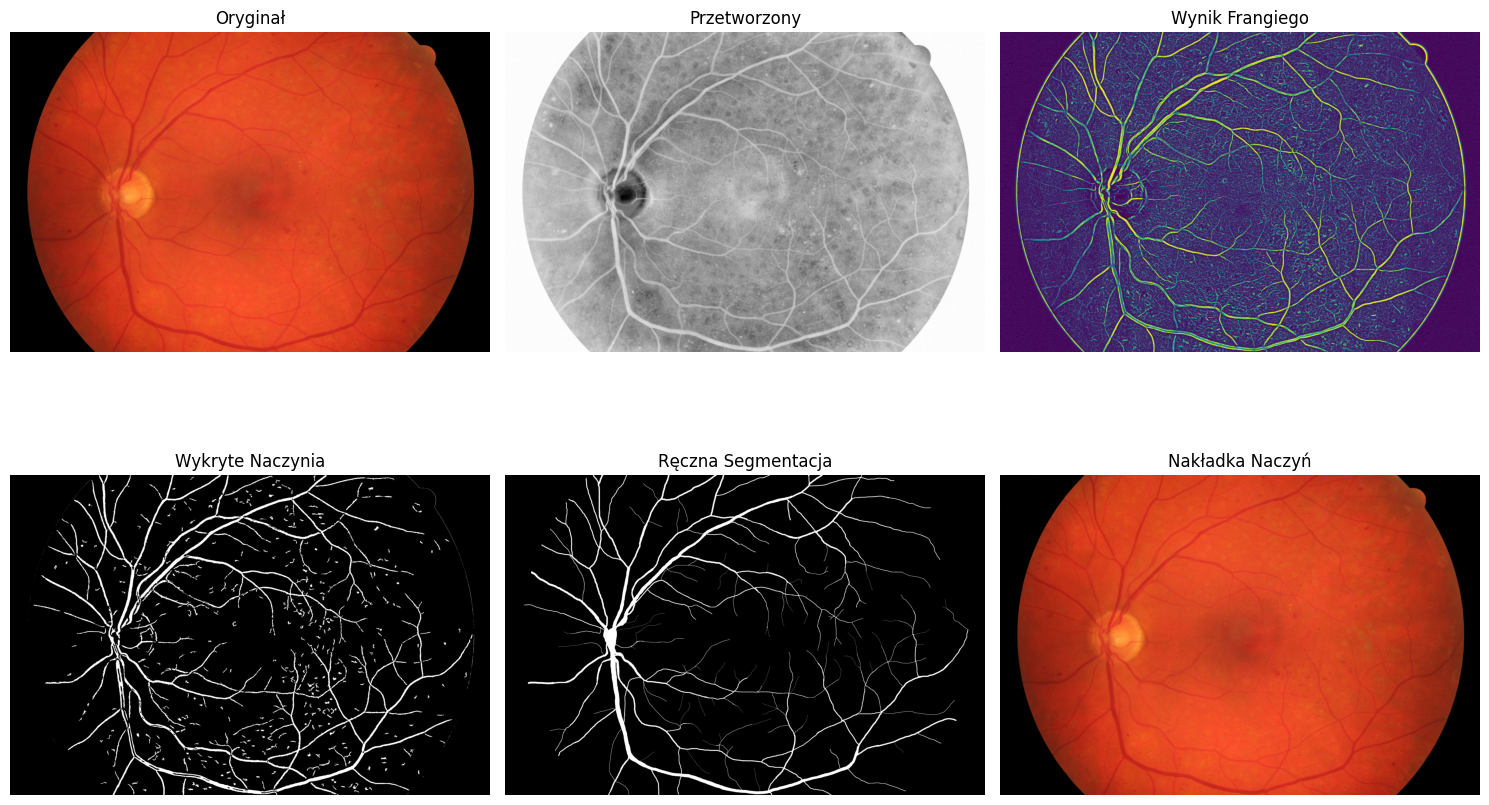

In [192]:
compare_results(
    dnoOka[0], 
    processed[0], 
    vessels[0], 
    binaries[0], 
    naczynia[0]
)

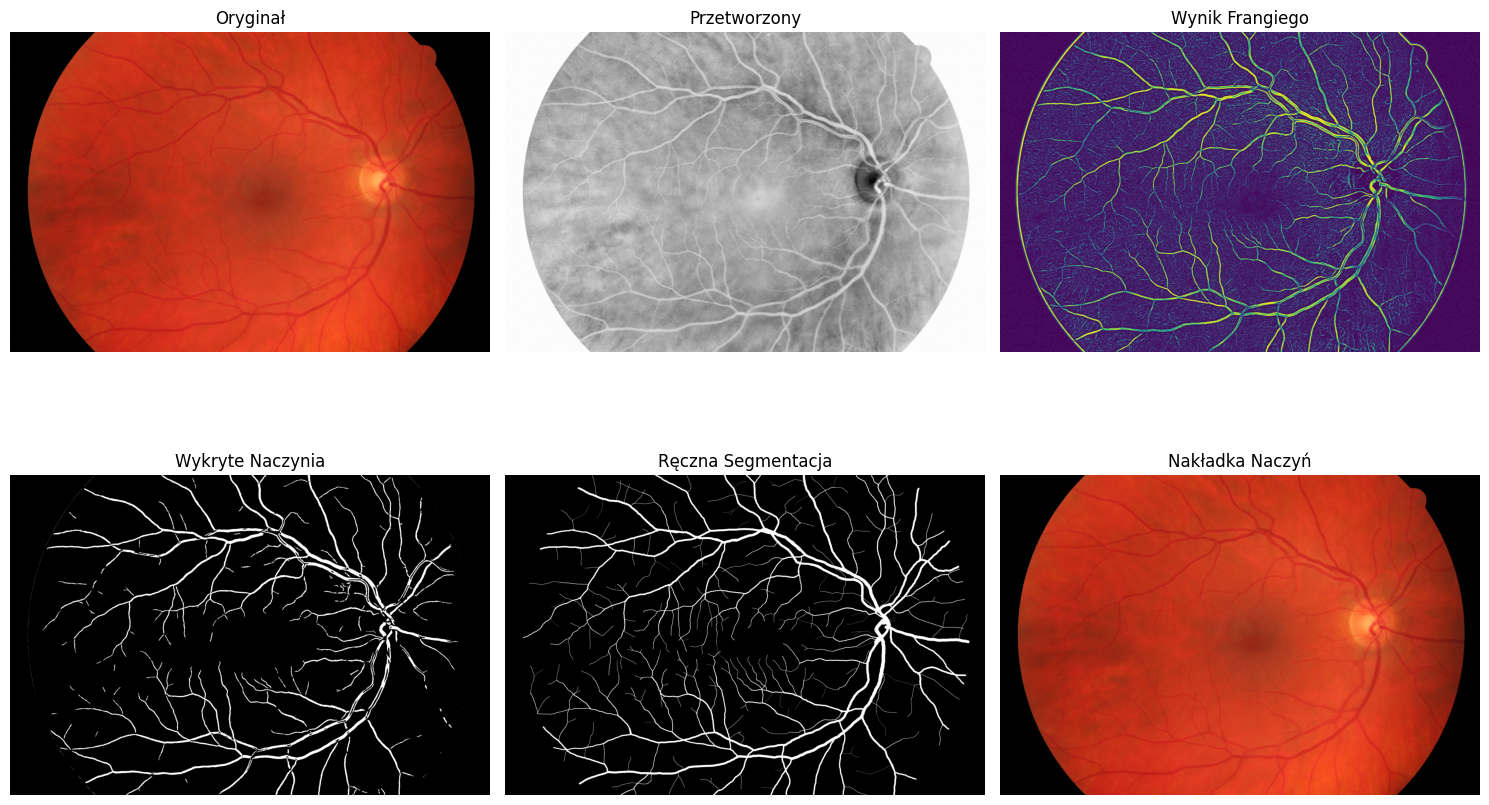

In [193]:
compare_results(
    dnoOka[1], 
    processed[1], 
    vessels[1], 
    binaries[1], 
    naczynia[1]
)

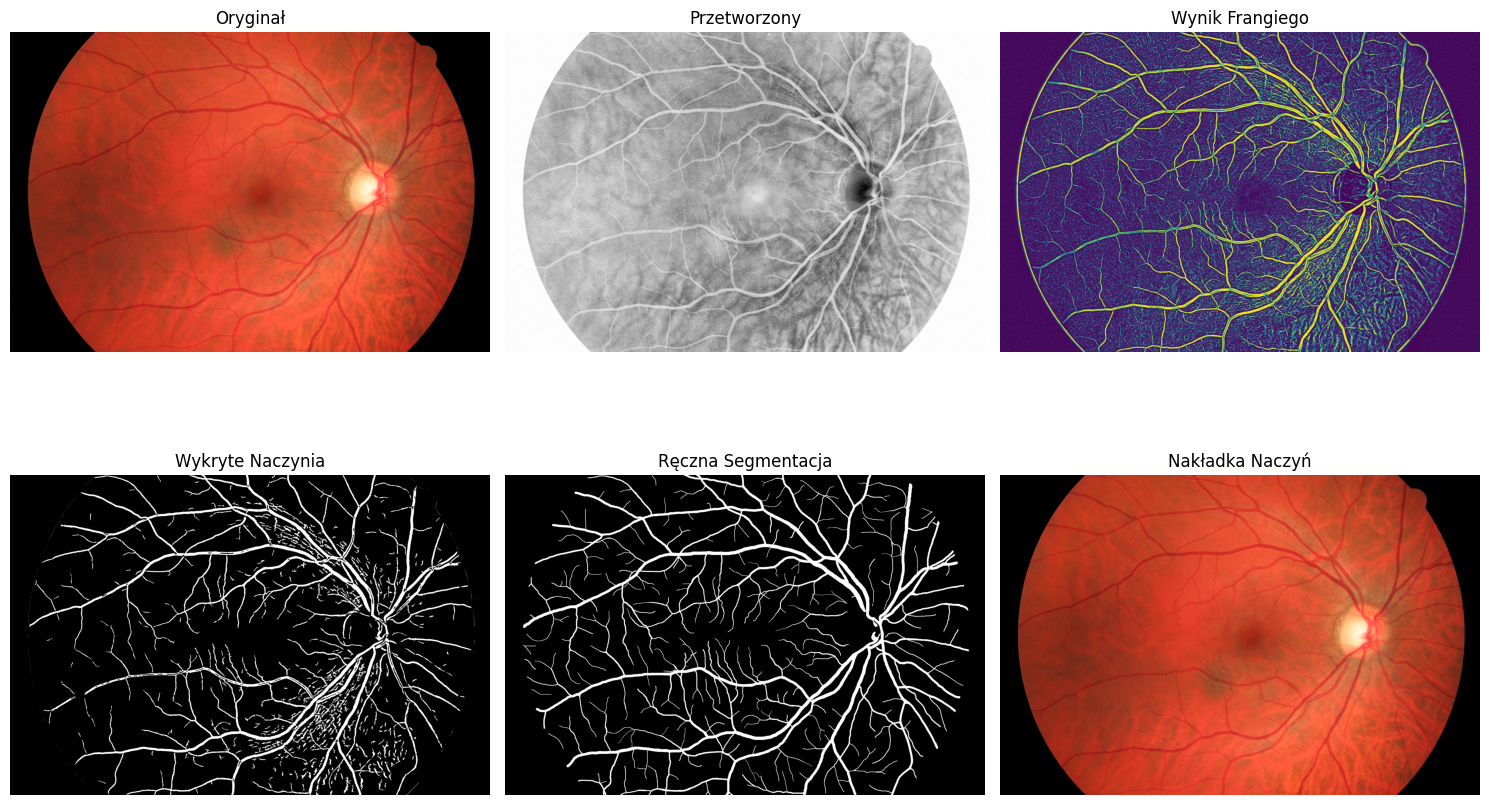

In [194]:
compare_results(
    dnoOka[2], 
    processed[2], 
    vessels[2], 
    binaries[2], 
    naczynia[2]
)

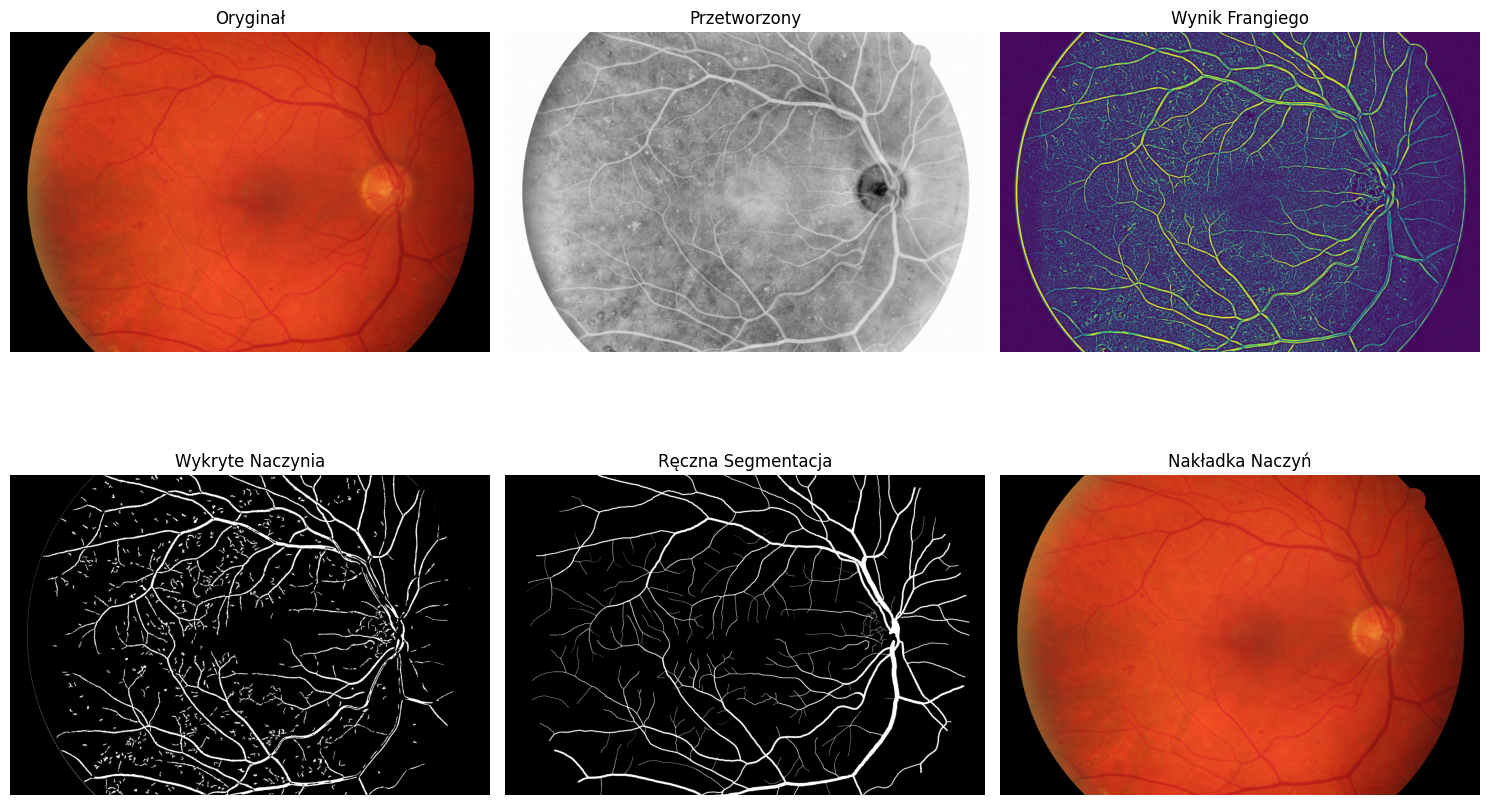

In [195]:
compare_results(
    dnoOka[3], 
    processed[3], 
    vessels[3], 
    binaries[3], 
    naczynia[3]
)

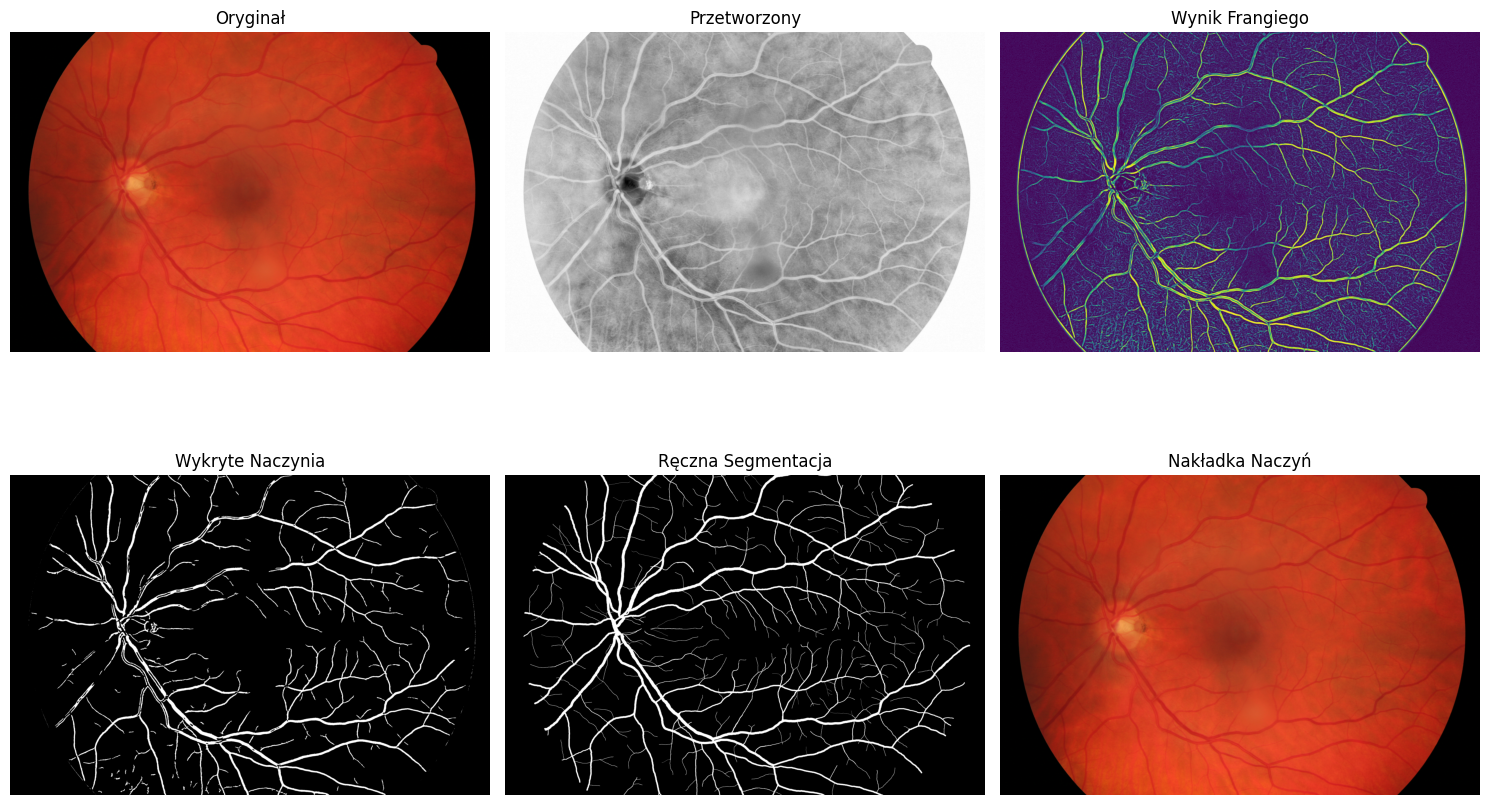

In [196]:
compare_results(
    dnoOka[4], 
    processed[4], 
    vessels[4], 
    binaries[4], 
    naczynia[4]
)